# SHAP Explanation

## Package Loading

In [21]:
import shap
from pickle import dump, load
import os
import skops.io as sio
import numpy as np

## Model and Data loading

In [22]:
with open('data/feature_sel/X_test.pkl', 'rb') as file:
    X_test = load(file)

with open('data/feature_sel/y_test.pkl', 'rb') as file:
    y_test = load(file)

unknown_types = sio.get_untrusted_types(file="data/modelling/model.skops")
model = sio.load("data/modelling/model.skops", trusted=unknown_types)
unknown_types = sio.get_untrusted_types(file="data/feature_eng/encoder.skops")
encoder = sio.load("data/feature_eng/encoder.skops", trusted=unknown_types)

display(X_test.head())
display(y_test.head())
display(model)
display(encoder.categories_)

,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary
6071,848,1.0,0.0,40,5,148495.64,158853.98
4407,612,2.0,0.0,36,5,119799.27,159416.58
1098,604,0.0,1.0,28,7,0.00,58595.64
9524,499,0.0,1.0,60,7,76961.60,83643.87
5294,624,0.0,0.0,38,3,0.00,163666.85


6071    0
4407    0
1098    0
9524    0
5294    0
Name: Exited, dtype: int64

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.12
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",1000
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",7
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.","['Geog

[array(['France', 'Germany', 'Spain'], dtype=object),
 array(['Female', 'Male'], dtype=object)]

**NOTES:**
* For country: France, Germany, and Spain encoded as 0, 1, and 2
* For Gender: Female and Male encoded as 0 and 1


## Prepare Explanation

In [23]:
## define log proba for model
def predict_log_proba(z):
    p = model.predict_proba(z)
    return np.log(p[:,1] / p[:,0])

background_data = shap.maskers.Independent(X_test, max_samples=100)
explainer = shap.Explainer(predict_log_proba, background_data)

## Get Explanation

In [24]:
shap_values = explainer(X_test) ## recompute shap values for entire dataset

ExactExplainer explainer: 2408it [01:20, 25.61it/s]                          


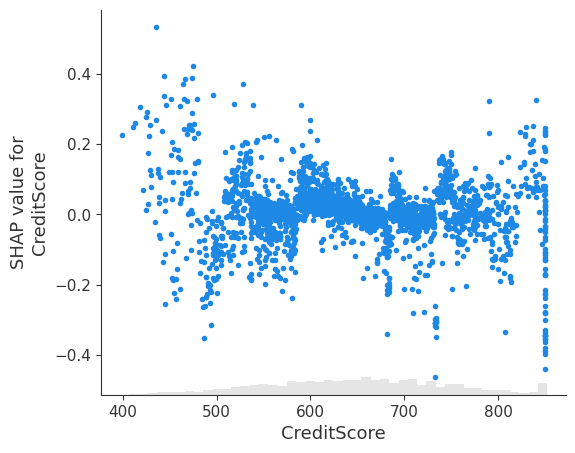

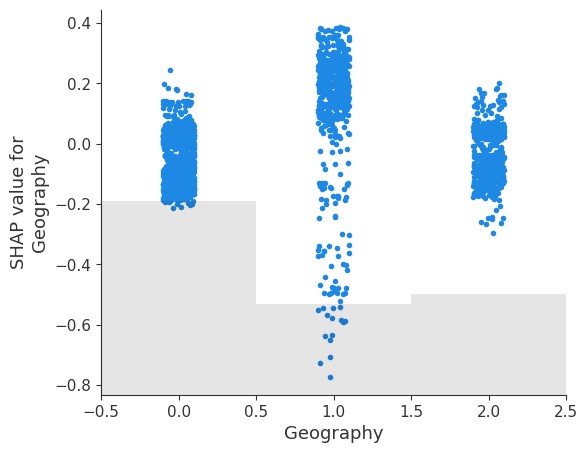

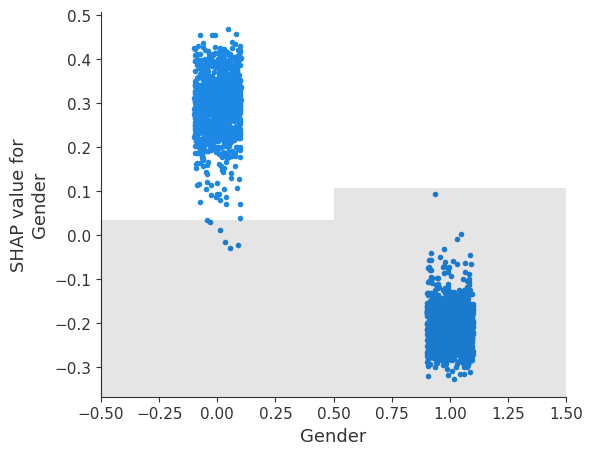

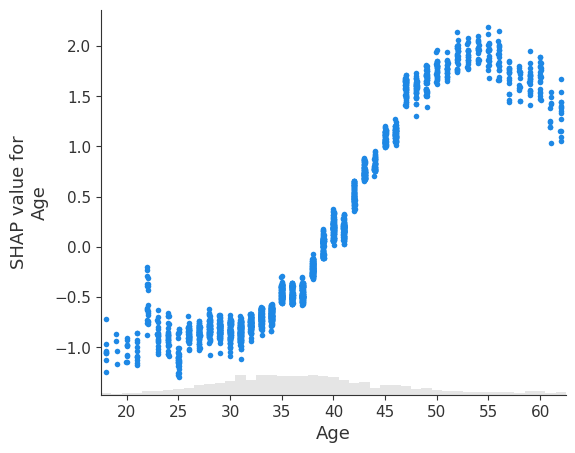

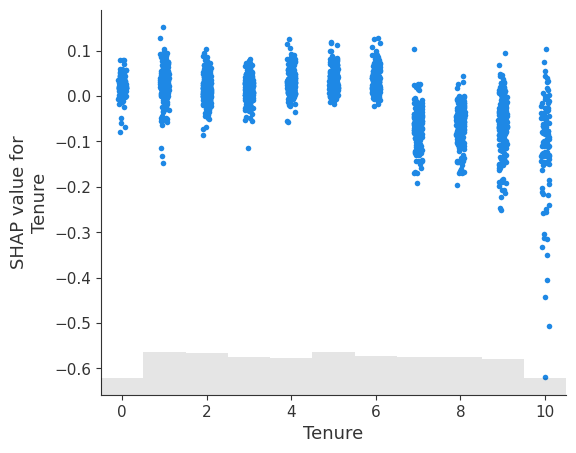

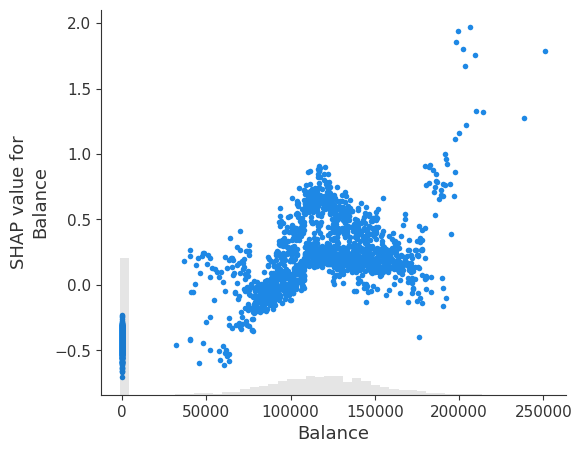

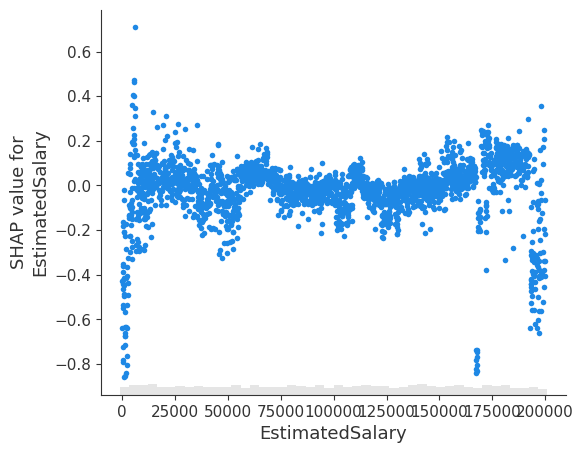

In [25]:
all_cols = list(X_test.columns)

# display(all_cols)

for col in all_cols:
    shap.plots.scatter(shap_values[:, col])

**Findings:**
* Positive SHAP value clusters on Country 1 (Germany) while mixed SHAP value clusters on other: German customers have some tendency to churn compared to other countries.
* Huge spread of SHAP value on Country 1 (Germany): German customer either love the product or they dont.
* Different clusters on Gender: Females tend to churn, while Males tend to stay.
* Pattern on Age: 38 year olds or younger tend to stay, while 39 year olds or older tend to churn. 
* Pattern on 7+ Tenure: Customer that stay for 7+ (years?) tend to stay. Some of those that already stay for 10 years seems more confident to stay
* Pattern on Balance: Customer with high amount of balance tend to churn more confidently. Customers with 0 balance tend to stay, probably to max out product benefit.
* Pattern on Estimated Salary: Customer with estimated salary between 75k to 150k tend to "less confident" to decide to become churn or not. Customers with estimated salary outside this range tend to "more confident" to decide to become churn or not

## Feature Importance

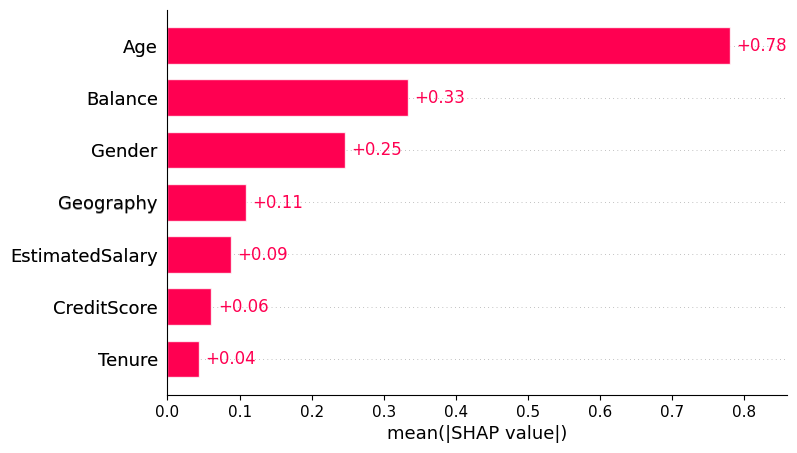

In [26]:
shap.plots.bar(shap_values)

Importance of feature, sorted from the most important to less important: Age, Balance, Gender, Geography, Estimated Salary, Credit Score, Tenure

## Save Explanation Result

In [27]:
if not os.path.exists('data/explainer'):
    os.makedirs('data/explainer')

with open('data/explainer/explainer.pkl', 'wb') as file:
    dump(explainer, file)

with open('data/explainer/shap_values.pkl', 'wb') as file:
    dump(shap_values, file)